In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("tested.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.shape

(418, 12)

In [5]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                                Kelly, Mr. James    male  34.5      0      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                       Myles, Mr. Thomas Francis    male  62.0      0      0   
3                                Wirz, Mr. Albert    male  27.0      0      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
..                       

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [8]:
import missingno as msno

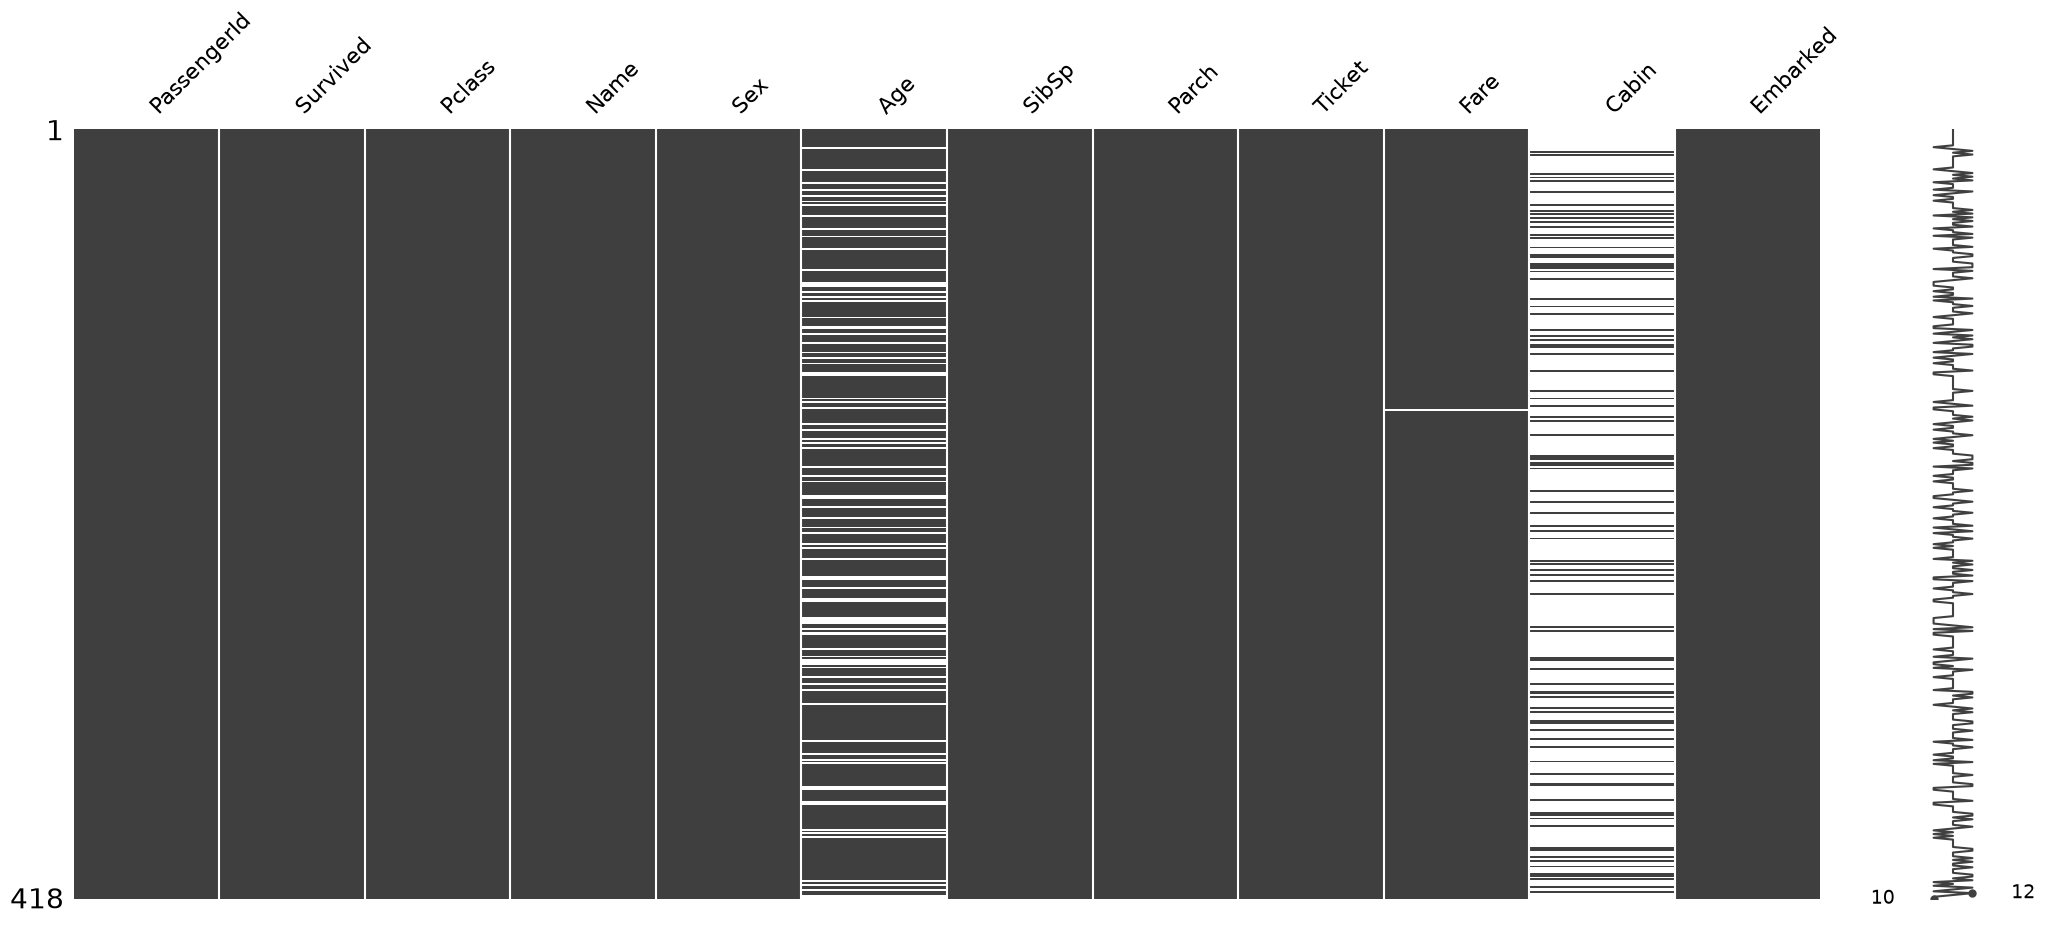

In [9]:
msno.matrix(df)
plt.show()

In [10]:
df["Fare"].fillna(
    df["Fare"].median(),
    inplace=True
)

C:\Users\diego\AppData\Local\Temp\ipykernel_63660\3756330137.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Fare"].fillna(


0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [11]:
df["Cabin"].fillna(
    df["Cabin"].mode(),
    inplace=True
)

C:\Users\diego\AppData\Local\Temp\ipykernel_63660\3036493343.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Cabin"].fillna(


0      B57 B59 B63 B66
1                  NaN
2                  NaN
3                  NaN
4                  NaN
            ...       
413                NaN
414               C105
415                NaN
416                NaN
417                NaN
Name: Cabin, Length: 418, dtype: str

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [13]:
df[df["Sex"]=="Age"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [14]:
df[df["Survived"]==1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
410,1302,1,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S


In [15]:
muestra = df.sample(
    n=50,
    random_state=42
)

muestra

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
321,1213,0,3,"Krekorian, Mr. Neshan",male,25.0,0,0,2654,7.2292,F E57,C
324,1216,1,1,"Kreuchen, Miss. Emilie",female,39.0,0,0,24160,211.3375,NaN,S
388,1280,0,3,"Canavan, Mr. Patrick",male,21.0,0,0,364858,7.7500,NaN,Q
56,948,0,3,"Cor, Mr. Bartol",male,35.0,0,0,349230,7.8958,NaN,S
153,1045,1,3,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0,2,350405,12.1833,NaN,S
30,922,0,2,"Louch, Mr. Charles Alexander",male,50.0,1,0,SC/AH 3085,26.0000,NaN,S
72,964,1,3,"Nieminen, Miss. Manta Josefina",female,29.0,0,0,3101297,7.9250,NaN,S
82,974,0,1,"Case, Mr. Howard Brown",male,49.0,0,0,19924,26.0000,NaN,S
258,1150,1,2,"Bentham, Miss. Lilian W",female,19.0,0,0,28404,13.0000,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [16]:
muestra.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,50.000000,50.000000,50.000000,40.000000,50.000000,50.000000,50.000000
mean,1106.520000,0.440000,2.240000,30.962500,0.360000,0.420000,32.828414
std,137.744253,0.501427,0.846602,12.335787,0.749422,1.371577,45.553058
min,901.000000,0.000000,1.000000,3.000000,0.000000,0.000000,7.229200
25%,970.250000,0.000000,1.250000,22.750000,0.000000,0.000000,8.050000
50%,1108.000000,0.000000,2.500000,29.000000,0.000000,0.000000,15.045800
75%,1249.250000,1.000000,3.000000,39.000000,0.750000,0.000000,28.773950
max,1308.000000,1.000000,3.000000,57.000000,4.000000,9.000000,211.500000


In [17]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [18]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,S


In [20]:
scaler = MinMaxScaler()

df[["Age","Fare"]] = scaler.fit_transform(
    df[["Age","Fare"]]
)

In [21]:
df[["Age","Fare"]].head()

,Age,Fare
0,0.452723,0.015282
1,0.617566,0.013663
2,0.815377,0.018909
3,0.353818,0.016908
4,0.287881,0.023984


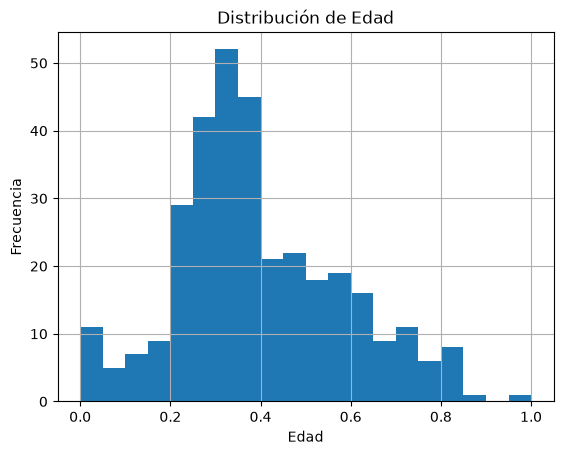

In [22]:
df["Age"].hist(
    bins=20
)

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

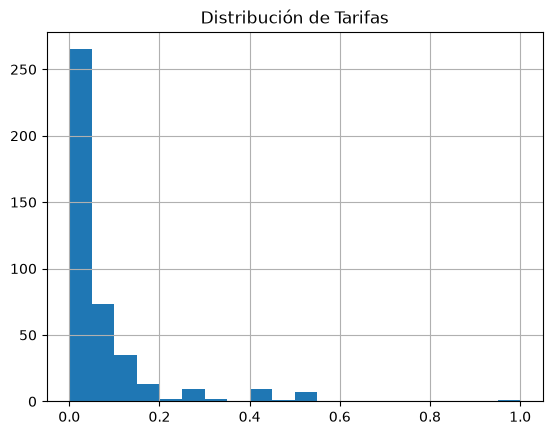

In [23]:
df["Fare"].hist(
    bins=20
)

plt.title("Distribución de Tarifas")
plt.show()

In [24]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [25]:
datos = df[
    ["Age", "Fare", "Sex", "Pclass"]
]

In [26]:
datos.isnull().sum()

Age        86
Fare        1
Sex       418
Pclass      0
dtype: int64

In [27]:
print("TIPOS DE DATOS")
print(datos.dtypes)

print("\nVALORES NULOS")
print(datos.isnull().sum())

print("\nPRIMEROS REGISTROS")
print(datos.head())

TIPOS DE DATOS
Age       float64
Fare      float64
Sex       float64
Pclass      int64
dtype: object

VALORES NULOS
Age        86
Fare        1
Sex       418
Pclass      0
dtype: int64

PRIMEROS REGISTROS
        Age      Fare  Sex  Pclass
0  0.452723  0.015282  NaN       3
1  0.617566  0.013663  NaN       3
2  0.815377  0.018909  NaN       2
3  0.353818  0.016908  NaN       3
4  0.287881  0.023984  NaN       3


In [28]:
datos.iloc[:10]

,Age,Fare,Sex,Pclass
0,0.452723,0.015282,NaN,3
1,0.617566,0.013663,NaN,3
2,0.815377,0.018909,NaN,2
3,0.353818,0.016908,NaN,3
4,0.287881,0.023984,NaN,3
5,0.182382,0.018006,NaN,3
6,0.393380,0.014891,NaN,3
7,0.340630,0.056604,NaN,2
8,0.235131,0.014110,NaN,3
9,0.274693,0.047138,NaN,3


In [29]:
df = pd.read_csv("tested.csv")

In [30]:
df["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [31]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [32]:
df["Sex"].unique()

array([0, 1])

In [33]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

In [34]:
df[["Age","Sex"]].isnull().sum()

Age    0
Sex    0
dtype: int64

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

datos = df[
    ["Age",
     "Fare",
     "Sex",
     "Pclass"]
]

similitud = cosine_similarity(
    datos.iloc[:10]
)

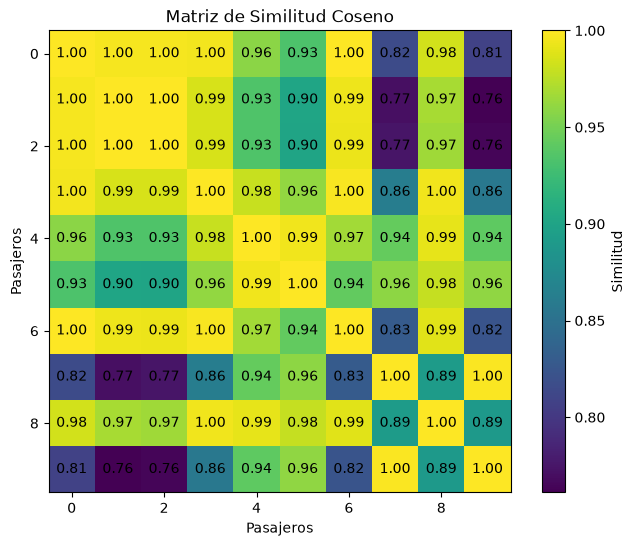

In [36]:
plt.figure(figsize=(8,6))

plt.imshow(similitud)

plt.colorbar(label="Similitud")

for i in range(similitud.shape[0]):
    for j in range(similitud.shape[1]):
        plt.text(
            j,
            i,
            f"{similitud[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de Similitud Coseno")
plt.xlabel("Pasajeros")
plt.ylabel("Pasajeros")

plt.show()